# Validation for BULK FORCE
We consider that $A$ is homogeneous, while $W=Aw(h)-c\epsilon x$ with $c=1$

# Continuation

In [85]:
import numpy as np
from matplotlib import pyplot as plt
def w(h):
    return (h**(-5)/5 + h**(-2)/2)
def dw(h):
    return (- h**(-6) + h**(-3))
def ddw(h):
    return (6*h**(-7) - 3*h**(-4))
# Continuation to compute h0in for different values of hmax or h0out
data = np.loadtxt(
    "continuation/2D_continuation.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K1 = data[1:, numrows-8]
K2 = data[1:, numrows-7]
GradW1 = data[1:, numrows-6]
GradW2 = data[1:, numrows-5]
H0out_lim = data[1:, numrows-4]
Hmax = data[1:, numrows-10]
h0out_formula = data[1:, numrows-9]
V = data[1:, numrows-11]
I = data[1:, numrows-12]
K = data[1:, numrows-13]
Omega = data[1:, numrows-14]
# Continuation (need to remove by hand (why???) the unstable branch)
par = data[1:, 3]
index = data[1:, 0]

i_branch = 16   # After this index it starts the droplet branch

# Pismen (2004)

$$3\eta \theta^{-1}h_a^{-2} \mathbf{U}\epsilon^{-1} K_{\text{Pismen}}=c V$$
where 
$$K_{\text{Pismen}} = K+h_m^{-2}I$$
and $U/\epsilon = v_1$

# Our formula
$$3 \eta h_{a}^{-1}K v_{1}=c h_{a}V+I(-ch_{a}+\partial_{\chi}H_{0}^{\mathrm{out}}
A h_{a}^{-2}
\partial_{HH}\omega(H_{0}^{\mathrm{out}}))$$

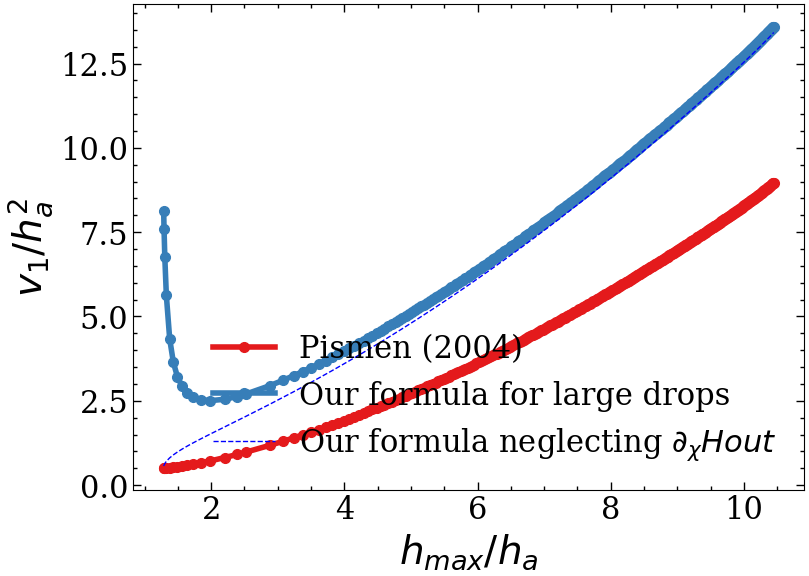

In [86]:
fig,ax = plt.subplots()
# Psimen (2004)
Kp = K+H0out_lim**(-2)*(I+GradW2)    # Inside I there is also the B field contribution that should not be included in the Pismen description
formula_Pismen = V/(3*Kp)
ax.plot(Hmax, formula_Pismen,'.-',label='Pismen (2004)')
# Our formula in the 'large drop limit'
formula_largedrop = V/(3*K)
ax.plot(Hmax, formula_largedrop,'.-',label='Our formula for large drops')
# Our formula neglecting variations of H0out
formula_noHout = (V-I)/(3*K)
ax.plot(Hmax, formula_noHout,label='Our formula neglecting $\\partial_{\\chi}Hout$',ls='--',color='blue',lw='1')
# Full formula (non-neglecting the I term)
ha = 1e-2
#plt.plot(Hmax, (V-I+ha**(-3))/(3*K),'.-',label='Our formula for large drops')

ax.set_xlabel('$h_{max}/h_a$')
ax.set_ylabel('$v_1/h_a^2$')
plt.grid
plt.legend()

# Time solver

In [87]:
from pathlib import Path
import numpy as np
import re
from matplotlib import pyplot as plt


def analyze_simulation(directory):

    directory = Path(directory)

    results = []

    for filename in sorted(directory.glob("*.txt")):

        # Read header
        with open(filename, "r") as f:
            header = f.readline().strip()

        # Extract time from "@time=..."
        match = re.search(r"@time=([0-9.eE+-]+)", header)

        if match is None:
            print(f"Could not find time in {filename}")
            continue

        time = float(match.group(1))

        # Read x, y, h, p
        data = np.loadtxt(filename, comments="#")

        x = data[:, 0]
        y = data[:, 1]
        h = data[:, 2]

        # Location of maximum h
        i = np.argmax(h)

        xmax = x[i]
        ymax = y[i]
        hmax = h[i]

        results.append([time, xmax, ymax, hmax])

    # Sort by time
    results = np.array(results)
    results = results[np.argsort(results[:, 0])]

    return results

In [88]:
ha=0.01
eps=0.1

hcvec = [0.025,0.05,0.05,0.1,0.25,0.5,0.75,1]
hmax_vec = []
xdot_vec = []
for hc in hcvec:
    res=analyze_simulation(f"../pyoomph_tutorial_scripts/SpatioTemporal_PDEs/single_droplet_hcenter_{hc:g}/domain")
    hmax_ = res[-1,3]
    data = np.loadtxt(f"../pyoomph_tutorial_scripts/SpatioTemporal_PDEs/single_droplet_hcenter_{hc:g}/obs_hcenter_{hc:g}.txt", skiprows=1)
    print(hc)
    t = data[:,0]
    xcm = data[:,2]/data[:,1]   # Numerator and denominator integrals are computed separately
    #plt.plot(t,xcm,'*')
    c=np.polyfit(t[-5:-1],xcm[-5:-1],deg=1)
    xdot_vec.append(c[0])
    hmax_vec.append(hmax_)

ax.plot(np.array(hmax_vec)/ha,np.array(xdot_vec)/(eps*ha**2),'*')
#plt.xlabel('hmax/ha')
#plt.ylabel('v1/ha^2')

# Pismen (2004) with continuation to compute the integrals
#plt.plot(hmax,V/(3*K))


0.025
0.05
0.05
0.1
0.25
0.5
0.75
1


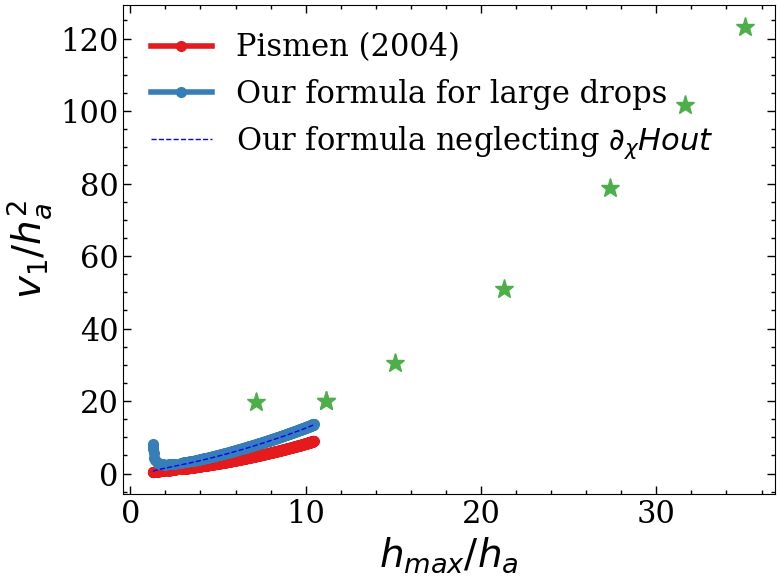

In [89]:
fig

# Validation for DISORDER
We take $c=0$ and $A=1+\epsilon x$

# Our formula
$$3 \eta h_{a}K v_{1}=-\partial_{\chi}A \hat{\Omega}+I(\partial_{\chi}A\partial_{H}\omega_0^{\mathrm{out}}+\partial_{\chi}H_{0}^{\mathrm{out}}A\partial_{HH}\omega_0^{\mathrm{out}})$$

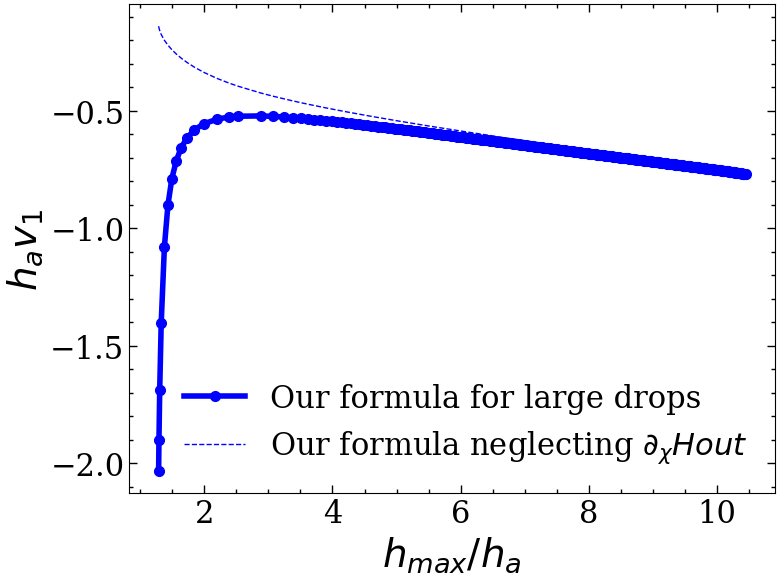

In [90]:
fig,ax = plt.subplots()

# Our formula in the 'large drop limit'
formula_largedrop = -Omega/(3*K)
ax.plot(Hmax, formula_largedrop,'.-',label='Our formula for large drops',color='blue')
# Full formula (non-neglecting the variations of Hout)
formula_noHout = (-Omega+I*dw(H0out_lim))/(3*K)
ax.plot(Hmax, formula_noHout,label='Our formula neglecting $\\partial_{\\chi}Hout$',ls='--',color='blue',lw='1')
ha = 1e-2
#plt.plot(Hmax, (V-I+ha**(-3))/(3*K),'.-',label='Our formula for large drops')

ax.set_xlabel('$h_{max}/h_a$')
ax.set_ylabel('$h_a v_1$')
plt.grid
plt.legend()

In [91]:
ha=0.01
eps=0.1

hcvec = [0.03,0.05,0.5]
hmax_vec = []
xdot_vec = []
for hc in hcvec:
    res=analyze_simulation(f"../pyoomph_tutorial_scripts/SpatioTemporal_PDEs/single_droplet_hcenter_{hc:g}/domain")
    hmax_ = res[-1,3]
    data = np.loadtxt(f"../pyoomph_tutorial_scripts/SpatioTemporal_PDEs/single_droplet_hcenter_{hc:g}/obs_hcenter_{hc:g}.txt", skiprows=1)
    print(hc)
    t = data[:,0]
    xcm = data[:,2]/data[:,1]   # Numerator and denominator integrals are computed separately
    #plt.plot(t,xcm,'*')
    c=np.polyfit(t[-5:-1],xcm[-5:-1],deg=1)
    xdot_vec.append(c[0])
    hmax_vec.append(hmax_)

ax.plot(np.array(hmax_vec)/ha,np.array(xdot_vec)*ha/(eps),'*')
#plt.xlabel('hmax/ha')
#plt.ylabel('v1/ha^2')

# Pismen (2004) with continuation to compute the integrals
#plt.plot(hmax,V/(3*K))


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

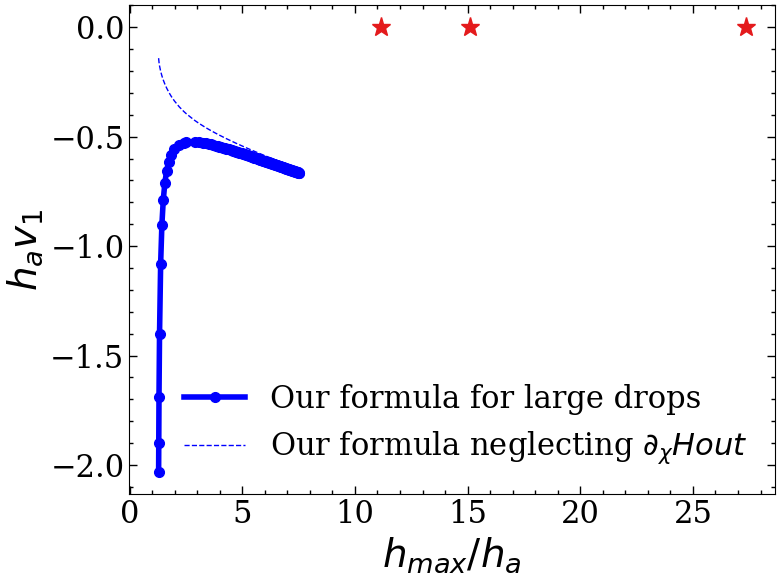

In [ ]:
fig